# Прогнозирование цены золота на горизонте 30 дней

**Курс:** Технологии искусственного интеллекта и продвинутой аналитики  
**Программа:** НИУ ВШЭ, магистратура «Бизнес-IT архитектура высокотехнологичных компаний»  
**Команда проекта:** Юсупов Данил, Панчук Павел, Маликов Евгений

## Бизнес-контекст

Золото является одним из ключевых защитных активов. Его цена важна для инвесторов, банков, риск-менеджеров, компаний сырьевого сектора и аналитиков финансового рынка. Прогноз цены золота помогает:

- оценивать рыночные риски и сценарии движения защитных активов;
- принимать инвестиционные решения и управлять портфелем;
- планировать закупки и хеджирование для компаний, связанных с металлами;
- анализировать взаимосвязи золота с долларом США, нефтью, акциями, серебром и доходностью облигаций.

## ML-формулировка

Задача формулируется как **регрессия временного ряда**: на основе исторических цен золота и внешних рыночных признаков нужно спрогнозировать следующую цену закрытия.

- **Целевая переменная:** `target_next_day = gold_close.shift(-1)`.
- **Основной тикер:** `GC=F` — Gold Futures.
- **Горизонт прогноза:** 30 дней.
- **Шаг прогноза:** 1 день.
- **Основная метрика:** MAE.
- **Дополнительные метрики:** RMSE, MAPE, R².

Для прогноза на 30 дней используется итеративный подход: модель предсказывает цену следующего дня, затем это предсказание добавляется в ряд, признаки пересчитываются, и процесс повторяется до горизонта 30 дней.

## 1. Импорты и настройки

В проекте используются стандартные библиотеки для работы с данными, визуализации, машинного обучения и сохранения артефактов. Дополнительные библиотеки (`xgboost`, `lightgbm`, `shap`) подключаются через `try/except`, чтобы ноутбук оставался воспроизводимым даже при отсутствии необязательных пакетов.

In [1]:
from pathlib import Path
from datetime import datetime
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import yfinance as yf

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    print(f"XGBoost недоступен: {exc}")

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception as exc:
    LGBMRegressor = None
    LIGHTGBM_AVAILABLE = False
    print(f"LightGBM недоступен: {exc}")

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    shap = None
    SHAP_AVAILABLE = False
    print(f"SHAP недоступен: {exc}")

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
IMAGES_DIR = PROJECT_ROOT / "images"
LANDING_DIR = PROJECT_ROOT / "landing"

for directory in [DATA_DIR, MODELS_DIR, IMAGES_DIR, LANDING_DIR]:
    directory.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Random state: {RANDOM_STATE}")

XGBoost недоступен: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/danilyusupov/Documents/HSE/Gold Predict ML/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/danilyusupov/Documents/HSE/Gold Predict ML/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Pre

LightGBM недоступен: dlopen(/Users/danilyusupov/Documents/HSE/Gold Predict ML/.venv/lib/python3.13/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <D44045CD-B874-3A27-9A61-F131D99AACE4> /Users/danilyusupov/Documents/HSE/Gold Predict ML/.venv/lib/python3.13/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/li

Project root: /Users/danilyusupov/Documents/HSE/Gold Predict ML
Random state: 42


## 2. Загрузка данных

Источник данных — библиотека `yfinance`, которая получает исторические рыночные данные из Yahoo Finance.

Используемые тикеры:

| Тикер | Признак | Смысл |
|---|---|---|
| `GC=F` | `gold_close` | фьючерс на золото, целевой актив |
| `DX-Y.NYB` | `usd_index_close` | индекс доллара США |
| `^GSPC` | `sp500_close` | индекс S&P 500 |
| `CL=F` | `wti_oil_close` | нефть WTI |
| `SI=F` | `silver_close` | серебро |
| `^TNX` | `us_10y_yield_close` | доходность 10-летних казначейских облигаций США |

Если часть тикеров временно недоступна, функция загрузки не останавливает весь проект: недоступные инструменты пропускаются, а доступные признаки сохраняются в CSV.

In [2]:
TICKERS = {
    "GC=F": "gold_close",
    "DX-Y.NYB": "usd_index_close",
    "^GSPC": "sp500_close",
    "CL=F": "wti_oil_close",
    "SI=F": "silver_close",
    "^TNX": "us_10y_yield_close",
}

START_DATE = "2010-01-01"
END_DATE = datetime.today().strftime("%Y-%m-%d")
CACHE_PATH = DATA_DIR / "gold_market_data.csv"


def _extract_close_series(raw_data: pd.DataFrame) -> pd.Series:
    """Возвращает Close/Adj Close из результата yfinance с учетом возможного MultiIndex."""
    if raw_data.empty:
        return pd.Series(dtype=float)

    if isinstance(raw_data.columns, pd.MultiIndex):
        for field in ["Close", "Adj Close"]:
            for level in range(raw_data.columns.nlevels):
                if field in raw_data.columns.get_level_values(level):
                    close_data = raw_data.xs(field, axis=1, level=level)
                    if isinstance(close_data, pd.DataFrame):
                        return close_data.iloc[:, 0]
                    return close_data
    else:
        for field in ["Close", "Adj Close"]:
            if field in raw_data.columns:
                return raw_data[field]

    raise ValueError("В данных yfinance не найдены колонки Close или Adj Close")


def load_market_data(tickers: dict, start_date: str, end_date: str, cache_path: Path, refresh: bool = False) -> pd.DataFrame:
    """Загружает дневные цены закрытия, кеширует результат и умеет читать данные из CSV."""
    cache_path = Path(cache_path)

    if cache_path.exists() and not refresh:
        data = pd.read_csv(cache_path, parse_dates=["date"])
        data = data.set_index("date").sort_index()
        print(f"Данные загружены из кеша: {cache_path}")
        return data

    series_list = []
    failed_tickers = {}

    for ticker, column_name in tickers.items():
        try:
            raw = yf.download(
                ticker,
                start=start_date,
                end=end_date,
                auto_adjust=False,
                progress=False,
                threads=False,
            )
            close_series = _extract_close_series(raw).rename(column_name)
            close_series = pd.to_numeric(close_series, errors="coerce")

            if close_series.dropna().empty:
                failed_tickers[ticker] = "пустая серия"
                continue

            series_list.append(close_series)
            print(f"Загружен {ticker} -> {column_name}: {close_series.dropna().shape[0]} наблюдений")
        except Exception as exc:
            failed_tickers[ticker] = str(exc)

    if not series_list:
        raise RuntimeError("Не удалось загрузить ни один тикер. Проверьте соединение с интернетом или CSV-кеш.")

    data = pd.concat(series_list, axis=1).sort_index()
    data = data[~data.index.duplicated(keep="last")]
    data = data.ffill().dropna(subset=["gold_close"])
    data.index.name = "date"
    data.to_csv(cache_path)

    if failed_tickers:
        print("Некоторые тикеры не были загружены:")
        for ticker, reason in failed_tickers.items():
            print(f"- {ticker}: {reason}")

    print(f"Итоговые данные сохранены: {cache_path}")
    return data


market_data = load_market_data(TICKERS, START_DATE, END_DATE, CACHE_PATH)
print(f"Размер данных: {market_data.shape[0]} строк × {market_data.shape[1]} столбцов")
display(market_data.head())

Загружен GC=F -> gold_close: 4128 наблюдений


Загружен DX-Y.NYB -> usd_index_close: 4130 наблюдений


Загружен ^GSPC -> sp500_close: 4129 наблюдений


Загружен CL=F -> wti_oil_close: 4129 наблюдений


Загружен SI=F -> silver_close: 4128 наблюдений


Загружен ^TNX -> us_10y_yield_close: 4127 наблюдений
Итоговые данные сохранены: /Users/danilyusupov/Documents/HSE/Gold Predict ML/data/gold_market_data.csv
Размер данных: 4133 строк × 6 столбцов


,gold_close,usd_index_close,sp500_close,wti_oil_close,silver_close,us_10y_yield_close
date,,,,,,
2010-01-04,"1,117.7000",77.5300,"1,132.9900",81.5100,17.4400,3.8410
2010-01-05,"1,118.1000",77.6200,"1,136.5200",81.7700,17.7810,3.7550
2010-01-06,"1,135.9000",77.4900,"1,137.1400",83.1800,18.1630,3.8080
2010-01-07,"1,133.1000",77.9100,"1,141.6899",82.6600,18.3330,3.8220
2010-01-08,"1,138.2000",77.4700,"1,144.9800",82.7500,18.4580,3.8080


## 3. Первичный анализ данных

На этом этапе проверяем структуру датасета, пропуски, дубликаты, период наблюдений и базовую статистику цены золота. Для временного ряда особенно важно понимать, где есть пропуски и как менялось распределение цены и доходности во времени.

In [3]:
print("Первые строки:")
display(market_data.head())

print("\nИнформация о данных:")
market_data.info()

print("\nОписательная статистика:")
display(market_data.describe().T)

missing_table = market_data.isna().sum().to_frame("missing_count")
missing_table["missing_share"] = missing_table["missing_count"] / len(market_data)
print("\nПропуски:")
display(missing_table)

duplicates_count = market_data.index.duplicated().sum()
print(f"Дубликаты по индексу дат: {duplicates_count}")
print(f"Период данных: {market_data.index.min().date()} — {market_data.index.max().date()}")
print(f"Количество календарных лет в данных: {market_data.index.year.nunique()}")

returns = market_data["gold_close"].pct_change().dropna()
gold_stats = pd.DataFrame({
    "metric": ["min", "max", "mean", "median", "std", "last"],
    "gold_close": [
        market_data["gold_close"].min(),
        market_data["gold_close"].max(),
        market_data["gold_close"].mean(),
        market_data["gold_close"].median(),
        market_data["gold_close"].std(),
        market_data["gold_close"].iloc[-1],
    ],
})
print("\nБазовая статистика цены золота:")
display(gold_stats)

Первые строки:


,gold_close,usd_index_close,sp500_close,wti_oil_close,silver_close,us_10y_yield_close
date,,,,,,
2010-01-04,"1,117.7000",77.5300,"1,132.9900",81.5100,17.4400,3.8410
2010-01-05,"1,118.1000",77.6200,"1,136.5200",81.7700,17.7810,3.7550
2010-01-06,"1,135.9000",77.4900,"1,137.1400",83.1800,18.1630,3.8080
2010-01-07,"1,133.1000",77.9100,"1,141.6899",82.6600,18.3330,3.8220
2010-01-08,"1,138.2000",77.4700,"1,144.9800",82.7500,18.4580,3.8080



Информация о данных:
<class 'pandas.DataFrame'>
DatetimeIndex: 4133 entries, 2010-01-04 to 2026-06-03
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gold_close          4133 non-null   float64
 1   usd_index_close     4133 non-null   float64
 2   sp500_close         4133 non-null   float64
 3   wti_oil_close       4133 non-null   float64
 4   silver_close        4133 non-null   float64
 5   us_10y_yield_close  4133 non-null   float64
dtypes: float64(6)
memory usage: 226.0 KB

Описательная статистика:


,count,mean,std,min,25%,50%,75%,max
gold_close,"4,133.0000","1,743.0856",758.5026,"1,050.8000","1,272.0000","1,537.8000","1,854.5000","5,318.3999"
usd_index_close,"4,133.0000",92.8863,9.2960,72.9300,82.6800,95.4200,99.1800,114.1100
sp500_close,"4,133.0000","3,049.5234","1,605.3275","1,022.5800","1,838.8800","2,648.0500","4,158.7700","7,609.7798"
wti_oil_close,"4,133.0000",71.8171,20.8048,-37.6300,55.2100,71.6900,88.8200,123.7000
silver_close,"4,133.0000",24.6069,12.0414,11.7350,17.0540,21.6840,28.2920,115.0800
us_10y_yield_close,"4,133.0000",2.6478,1.0267,0.4990,1.8720,2.4910,3.4550,4.9880



Пропуски:


,missing_count,missing_share
gold_close,0,0.0000
usd_index_close,0,0.0000
sp500_close,0,0.0000
wti_oil_close,0,0.0000
silver_close,0,0.0000
us_10y_yield_close,0,0.0000


Дубликаты по индексу дат: 0
Период данных: 2010-01-04 — 2026-06-03
Количество календарных лет в данных: 17

Базовая статистика цены золота:


,metric,gold_close
0,min,"1,050.8000"
1,max,"5,318.3999"
2,mean,"1,743.0856"
3,median,"1,537.8000"
4,std,758.5026
5,last,"4,436.7002"


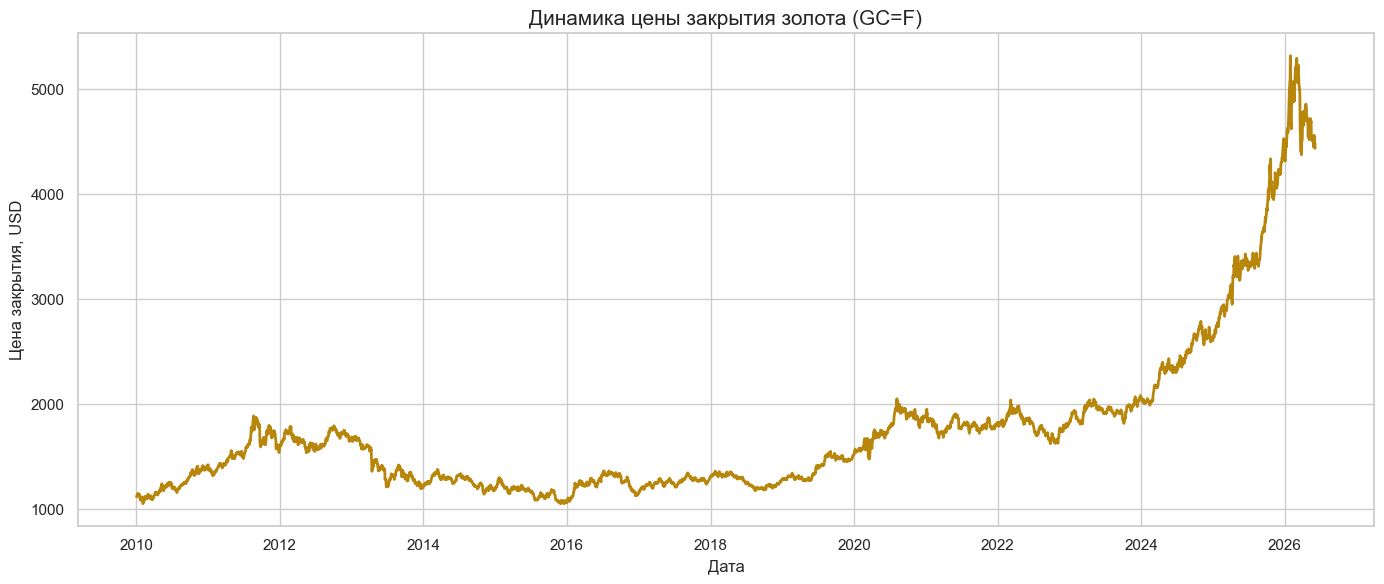

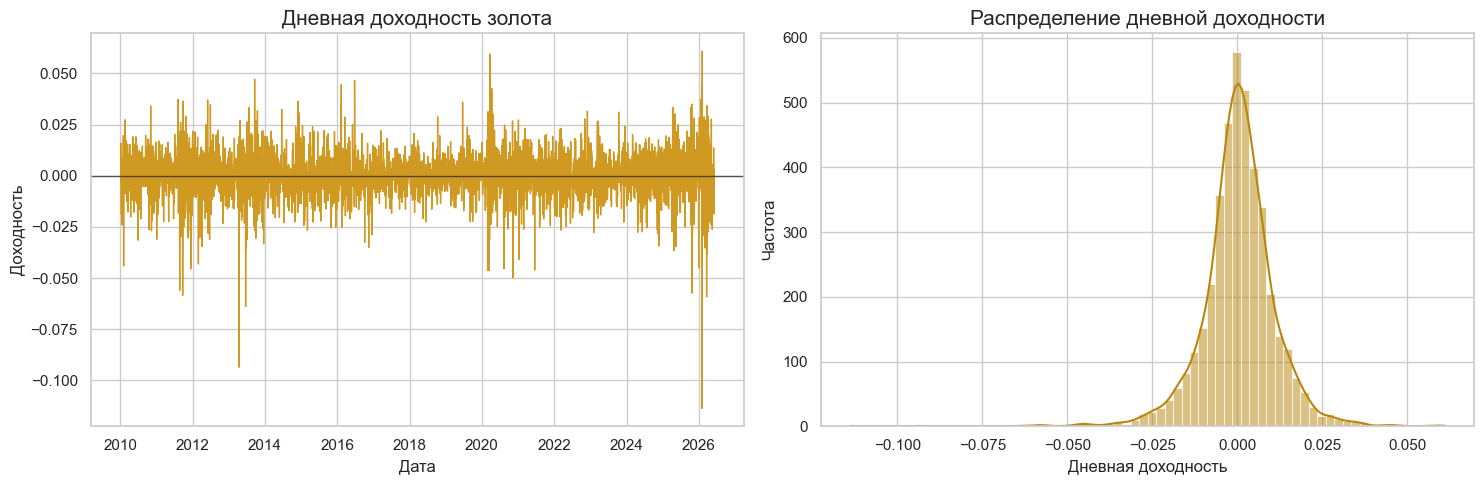

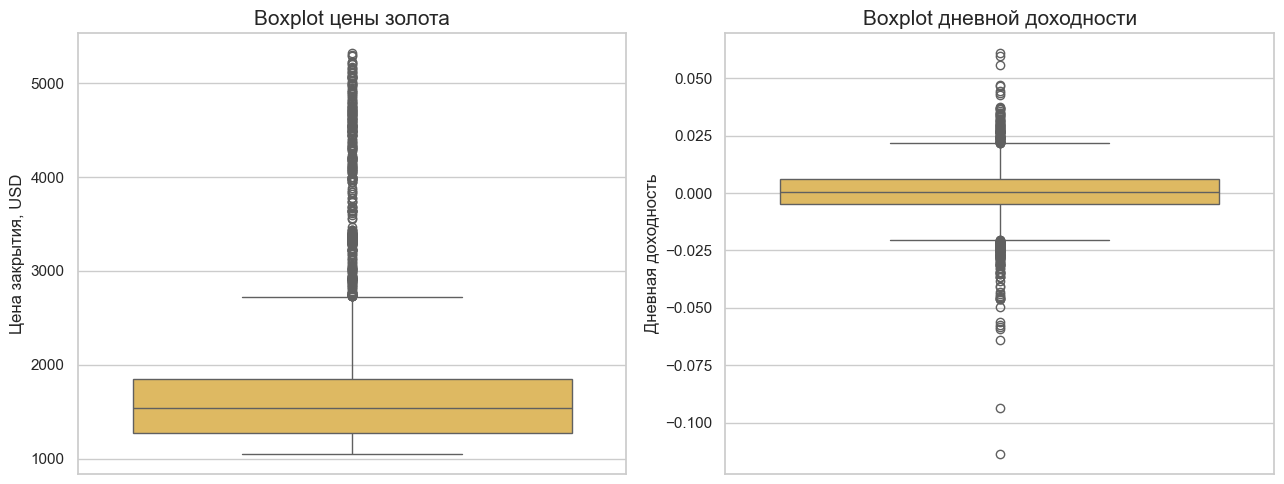

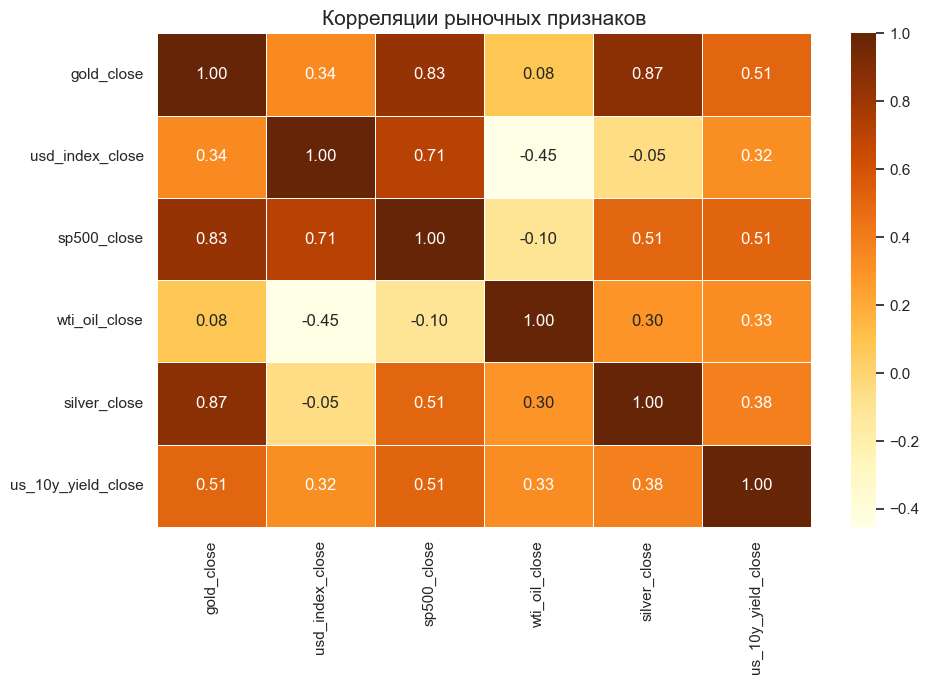

In [4]:
def save_current_figure(path: Path):
    """Сохраняет текущий matplotlib-график в хорошем качестве."""
    path.parent.mkdir(exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()

# Динамика цены золота
plt.figure(figsize=(14, 6))
sns.lineplot(data=market_data, x=market_data.index, y="gold_close", color="#b8860b", linewidth=2)
plt.title("Динамика цены закрытия золота (GC=F)")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия, USD")
save_current_figure(IMAGES_DIR / "eda_gold_price.png")

# Дневная доходность и распределение
returns = market_data["gold_close"].pct_change().dropna()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(x=returns.index, y=returns.values, ax=axes[0], color="#d09a22", linewidth=1)
axes[0].axhline(0, color="#202020", linewidth=1, alpha=0.7)
axes[0].set_title("Дневная доходность золота")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Доходность")
sns.histplot(returns, bins=70, kde=True, ax=axes[1], color="#b8860b")
axes[1].set_title("Распределение дневной доходности")
axes[1].set_xlabel("Дневная доходность")
axes[1].set_ylabel("Частота")
save_current_figure(IMAGES_DIR / "eda_returns_distribution.png")

# Boxplot цены и доходности
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(y=market_data["gold_close"], ax=axes[0], color="#f2c14e")
axes[0].set_title("Boxplot цены золота")
axes[0].set_ylabel("Цена закрытия, USD")
sns.boxplot(y=returns, ax=axes[1], color="#f2c14e")
axes[1].set_title("Boxplot дневной доходности")
axes[1].set_ylabel("Дневная доходность")
save_current_figure(IMAGES_DIR / "eda_boxplots.png")

# Корреляции
corr = market_data.dropna().corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlOrBr", linewidths=0.5)
plt.title("Корреляции рыночных признаков")
save_current_figure(IMAGES_DIR / "eda_correlation_heatmap.png")

## 4. Feature Engineering

Для прогнозирования следующей цены закрытия используются признаки, доступные на момент текущего дня:

- лаги цены золота: 1, 2, 3, 7, 14 и 30 дней;
- скользящие средние: 7, 14, 30 и 90 дней;
- историческая волатильность: 7, 14 и 30 дней;
- доходности золота: 1, 7 и 30 дней;
- календарные признаки;
- внешние рыночные признаки и их краткосрочная динамика.

Целевая переменная — цена золота на следующий день: `target_next_day = gold_close.shift(-1)`.

In [5]:
def prepare_features(data: pd.DataFrame) -> pd.DataFrame:
    """Создает признаки временного ряда и целевую переменную следующего дня."""
    df = data.copy().sort_index()

    # Лаги цены золота отражают краткосрочную и среднесрочную память ряда.
    for lag in [1, 2, 3, 7, 14, 30]:
        df[f"gold_lag_{lag}"] = df["gold_close"].shift(lag)

    # Rolling-признаки сглаживают шум и описывают локальный тренд.
    for window in [7, 14, 30, 90]:
        df[f"sma_{window}"] = df["gold_close"].rolling(window=window).mean()

    for window in [7, 14, 30]:
        df[f"volatility_{window}"] = df["gold_close"].pct_change().rolling(window=window).std()

    for period in [1, 7, 30]:
        df[f"return_{period}d"] = df["gold_close"].pct_change(periods=period)

    # Календарные признаки помогают модели учитывать сезонность торговых дней.
    df["day_of_week"] = df.index.dayofweek
    df["month"] = df.index.month
    df["quarter"] = df.index.quarter
    df["year"] = df.index.year
    df["is_month_start"] = df.index.is_month_start.astype(int)
    df["is_month_end"] = df.index.is_month_end.astype(int)

    external_columns = [col for col in data.columns if col != "gold_close"]
    for col in external_columns:
        df[f"{col}_return_1d"] = df[col].pct_change()
        df[f"{col}_lag_1"] = df[col].shift(1)

    df["target_next_day"] = df["gold_close"].shift(-1)
    return df


features_raw = prepare_features(market_data)
features_raw = features_raw.replace([np.inf, -np.inf], np.nan)

print(f"Размер таблицы с признаками до очистки: {features_raw.shape}")
display(features_raw.head())

Размер таблицы с признаками до очистки: (4133, 39)


,gold_close,usd_index_close,sp500_close,wti_oil_close,silver_close,us_10y_yield_close,gold_lag_1,gold_lag_2,gold_lag_3,gold_lag_7,gold_lag_14,gold_lag_30,sma_7,sma_14,sma_30,sma_90,volatility_7,volatility_14,volatility_30,return_1d,return_7d,return_30d,day_of_week,month,quarter,year,is_month_start,is_month_end,usd_index_close_return_1d,usd_index_close_lag_1,sp500_close_return_1d,sp500_close_lag_1,wti_oil_close_return_1d,wti_oil_close_lag_1,silver_close_return_1d,silver_close_lag_1,us_10y_yield_close_return_1d,us_10y_yield_close_lag_1,target_next_day
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-04,"1,117.7000",77.5300,"1,132.9900",81.5100,17.4400,3.8410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,2010,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,118.1000"
2010-01-05,"1,118.1000",77.6200,"1,136.5200",81.7700,17.7810,3.7550,"1,117.7000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0004,NaN,NaN,1,1,1,2010,0,0,0.0012,77.5300,0.0031,"1,132.9900",0.0032,81.5100,0.0196,17.4400,-0.0224,3.8410,"1,135.9000"
2010-01-06,"1,135.9000",77.4900,"1,137.1400",83.1800,18.1630,3.8080,"1,118.1000","1,117.7000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0159,NaN,NaN,2,1,1,2010,0,0,-0.0017,77.6200,0.0005,"1,136.5200",0.0172,81.7700,0.0215,17.7810,0.0141,3.7550,"1,133.1000"
2010-01-07,"1,133.1000",77.9100,"1,141.6899",82.6600,18.3330,3.8220,"1,135.9000","1,118.1000","1,117.7000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0025,NaN,NaN,3,1,1,2010,0,0,0.0054,77.4900,0.0040,"1,137.1400",-0.0063,83.1800,0.0094,18.1630,0.0037,3.8080,"1,138.2000"
2010-01-08,"1,138.2000",77.4700,"1,144.9800",82.7500,18.4580,3.8080,"1,133.1000","1,135.9000","1,118.1000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0045,NaN,NaN,4,1,1,2010,0,0,-0.0056,77.9100,0.0029,"1,141.6899",0.0011,82.6600,0.0068,18.3330,-0.0037,3.8220,"1,150.7000"


## 5. Предобработка и хронологическое разделение

После создания лагов и rolling-признаков появляются пропуски в первых строках, а после `shift(-1)` — в последней строке целевой переменной. Такие строки удаляются для обучения.

Случайный `train_test_split` для временного ряда использовать нельзя: он перемешивает прошлое и будущее, из-за чего модель может косвенно обучаться на информации из будущего. Поэтому используется хронологическое разделение:

- train: 70%;
- validation: 15%;
- test: 15%.

Выбросы не удаляются агрессивно, потому что резкие движения цены золота могут быть важной частью рыночной динамики.

In [6]:
def time_series_split(df: pd.DataFrame, train_size: float = 0.70, valid_size: float = 0.15):
    """Делит временной ряд на train/validation/test без перемешивания."""
    n_rows = len(df)
    train_end = int(n_rows * train_size)
    valid_end = int(n_rows * (train_size + valid_size))

    train = df.iloc[:train_end].copy()
    valid = df.iloc[train_end:valid_end].copy()
    test = df.iloc[valid_end:].copy()
    return train, valid, test


model_df = features_raw.dropna().copy()
model_df = model_df[~model_df.index.duplicated(keep="last")]

feature_columns = [col for col in model_df.columns if col != "target_next_day"]
target_column = "target_next_day"

train_df, valid_df, test_df = time_series_split(model_df)

X_train, y_train = train_df[feature_columns], train_df[target_column]
X_valid, y_valid = valid_df[feature_columns], valid_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

print(f"После очистки: {model_df.shape[0]} строк × {model_df.shape[1]} столбцов")
print(f"Train: {train_df.index.min().date()} — {train_df.index.max().date()}, {train_df.shape[0]} строк")
print(f"Validation: {valid_df.index.min().date()} — {valid_df.index.max().date()}, {valid_df.shape[0]} строк")
print(f"Test: {test_df.index.min().date()} — {test_df.index.max().date()}, {test_df.shape[0]} строк")
print(f"Количество признаков: {len(feature_columns)}")

display(pd.DataFrame(feature_columns, columns=["feature"]).head(30))

После очистки: 4043 строк × 39 столбцов
Train: 2010-05-12 — 2021-08-05, 2830 строк
Validation: 2021-08-06 — 2024-01-03, 606 строк
Test: 2024-01-04 — 2026-06-02, 607 строк
Количество признаков: 38


,feature
0,gold_close
1,usd_index_close
2,sp500_close
3,wti_oil_close
4,silver_close
5,us_10y_yield_close
6,gold_lag_1
7,gold_lag_2
8,gold_lag_3
9,gold_lag_7


## 6. Baseline-подходы

Перед обучением ML-моделей строим простые baseline-решения. Это нужно, чтобы понять, действительно ли модель приносит пользу.

1. **Naive forecast:** завтра цена равна сегодняшней.
2. **Moving average baseline:** прогноз через среднее за последние 7, 14 или 30 дней.

In [7]:
def calculate_metrics(y_true, y_pred) -> dict:
    """Считает основные метрики регрессии."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R2": r2_score(y_true, y_pred),
    }


def evaluate_baselines(split_name: str, X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    """Оценивает naive и moving average baseline на заданном периоде."""
    predictions = {
        "Naive forecast": X["gold_close"],
        "MA 7 baseline": X["sma_7"],
        "MA 14 baseline": X["sma_14"],
        "MA 30 baseline": X["sma_30"],
    }
    rows = []
    for name, pred in predictions.items():
        metrics = calculate_metrics(y, pred)
        rows.append({"Model": name, "Split": split_name, **metrics})
    return pd.DataFrame(rows)


baseline_valid = evaluate_baselines("validation", X_valid, y_valid)
baseline_test = evaluate_baselines("test", X_test, y_test)
baseline_results = pd.concat([baseline_valid, baseline_test], ignore_index=True)
baseline_results.to_csv(DATA_DIR / "baseline_results.csv", index=False)
display(baseline_results)

,Model,Split,MAE,RMSE,MAPE,R2
0,Naive forecast,validation,12.4969,16.6855,0.6727,0.9735
1,MA 7 baseline,validation,21.7581,27.7946,1.1732,0.9266
2,MA 14 baseline,validation,29.6851,37.3565,1.5987,0.8674
3,MA 30 baseline,validation,39.8311,49.4025,2.1426,0.7681
4,Naive forecast,test,33.7216,55.5879,0.9609,0.9963
5,MA 7 baseline,test,57.5855,86.3603,1.6343,0.9912
6,MA 14 baseline,test,73.6503,111.0333,2.1085,0.9854
7,MA 30 baseline,test,103.1367,152.4314,2.9496,0.9725


## 7. Моделирование

Сравниваем несколько моделей разной сложности:

- Linear Regression;
- Ridge Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- XGBoost Regressor или LightGBM Regressor, если библиотека доступна;
- MLPRegressor как простая нейросетевая модель.

Для линейных моделей и MLP используется `StandardScaler`, который обучается только на train. Validation и test трансформируются уже обученным scaler внутри `Pipeline`, что защищает от data leakage.

In [8]:
def create_estimator(model_key: str, params: dict):
    """Создает модель по ключу и набору гиперпараметров."""
    if model_key == "linear_regression":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression(**params)),
        ])

    if model_key == "ridge":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(random_state=RANDOM_STATE, **params)),
        ])

    if model_key == "random_forest":
        return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)

    if model_key == "gradient_boosting":
        return GradientBoostingRegressor(random_state=RANDOM_STATE, **params)

    if model_key == "xgboost" and XGBOOST_AVAILABLE:
        return XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            **params,
        )

    if model_key == "lightgbm" and LIGHTGBM_AVAILABLE:
        return LGBMRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            **params,
        )

    if model_key == "mlp":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(random_state=RANDOM_STATE, max_iter=700, **params)),
        ])

    raise ValueError(f"Неизвестная или недоступная модель: {model_key}")


MODEL_CONFIGS = [
    {
        "key": "linear_regression",
        "name": "Linear Regression",
        "params": [{}],
    },
    {
        "key": "ridge",
        "name": "Ridge Regression",
        "params": [{"alpha": 0.1}, {"alpha": 1.0}, {"alpha": 10.0}, {"alpha": 50.0}],
    },
    {
        "key": "random_forest",
        "name": "Random Forest Regressor",
        "params": [
            {"n_estimators": 220, "max_depth": 6, "min_samples_leaf": 2},
            {"n_estimators": 260, "max_depth": 10, "min_samples_leaf": 2},
            {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 4},
        ],
    },
    {
        "key": "gradient_boosting",
        "name": "Gradient Boosting Regressor",
        "params": [
            {"n_estimators": 220, "learning_rate": 0.03, "max_depth": 2, "subsample": 0.9},
            {"n_estimators": 260, "learning_rate": 0.04, "max_depth": 2, "subsample": 0.9},
            {"n_estimators": 220, "learning_rate": 0.03, "max_depth": 3, "subsample": 0.9},
        ],
    },
]

if XGBOOST_AVAILABLE:
    MODEL_CONFIGS.append({
        "key": "xgboost",
        "name": "XGBoost Regressor",
        "params": [
            {"n_estimators": 300, "learning_rate": 0.03, "max_depth": 2, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 1.0},
            {"n_estimators": 420, "learning_rate": 0.025, "max_depth": 3, "subsample": 0.9, "colsample_bytree": 0.8, "reg_lambda": 1.5},
        ],
    })
elif LIGHTGBM_AVAILABLE:
    MODEL_CONFIGS.append({
        "key": "lightgbm",
        "name": "LightGBM Regressor",
        "params": [
            {"n_estimators": 300, "learning_rate": 0.03, "num_leaves": 15, "subsample": 0.9, "colsample_bytree": 0.9},
            {"n_estimators": 420, "learning_rate": 0.025, "num_leaves": 31, "subsample": 0.9, "colsample_bytree": 0.8},
        ],
    })

if LIGHTGBM_AVAILABLE and XGBOOST_AVAILABLE:
    MODEL_CONFIGS.append({
        "key": "lightgbm",
        "name": "LightGBM Regressor",
        "params": [
            {"n_estimators": 300, "learning_rate": 0.03, "num_leaves": 15, "subsample": 0.9, "colsample_bytree": 0.9},
            {"n_estimators": 420, "learning_rate": 0.025, "num_leaves": 31, "subsample": 0.9, "colsample_bytree": 0.8},
        ],
    })

MODEL_CONFIGS.append({
    "key": "mlp",
    "name": "MLPRegressor",
    "params": [
        {"hidden_layer_sizes": (64, 32), "alpha": 0.001, "learning_rate_init": 0.001},
        {"hidden_layer_sizes": (96, 48), "alpha": 0.003, "learning_rate_init": 0.001},
    ],
})

print("Модели для сравнения:")
for cfg in MODEL_CONFIGS:
    print(f"- {cfg['name']}: {len(cfg['params'])} набор(а) параметров")

Модели для сравнения:
- Linear Regression: 1 набор(а) параметров
- Ridge Regression: 4 набор(а) параметров
- Random Forest Regressor: 3 набор(а) параметров
- Gradient Boosting Regressor: 3 набор(а) параметров
- MLPRegressor: 2 набор(а) параметров


In [9]:
def train_and_evaluate_model(config: dict, X_train, y_train, X_valid, y_valid, X_test, y_test) -> tuple:
    """Подбирает параметры на validation, затем оценивает лучшую модель на test."""
    validation_trials = []
    best_validation_mae = np.inf
    best_params = None
    best_training_time = None

    for params in config["params"]:
        estimator = create_estimator(config["key"], params)
        start_time = time.perf_counter()
        estimator.fit(X_train, y_train)
        training_time = time.perf_counter() - start_time

        valid_pred = estimator.predict(X_valid)
        valid_metrics = calculate_metrics(y_valid, valid_pred)
        validation_trials.append({
            "params": params,
            "training_time": training_time,
            **valid_metrics,
        })

        if valid_metrics["MAE"] < best_validation_mae:
            best_validation_mae = valid_metrics["MAE"]
            best_params = params
            best_training_time = training_time

    # Финальная модель обучается на train+validation с выбранными параметрами и оценивается на test.
    final_model = create_estimator(config["key"], best_params)
    X_train_valid = pd.concat([X_train, X_valid])
    y_train_valid = pd.concat([y_train, y_valid])

    start_time = time.perf_counter()
    final_model.fit(X_train_valid, y_train_valid)
    final_training_time = time.perf_counter() - start_time

    valid_model = create_estimator(config["key"], best_params)
    valid_model.fit(X_train, y_train)
    valid_pred = valid_model.predict(X_valid)
    test_pred = final_model.predict(X_test)

    valid_metrics = calculate_metrics(y_valid, valid_pred)
    test_metrics = calculate_metrics(y_test, test_pred)

    result = {
        "Model": config["name"],
        "MAE valid": valid_metrics["MAE"],
        "RMSE valid": valid_metrics["RMSE"],
        "MAPE valid": valid_metrics["MAPE"],
        "R2 valid": valid_metrics["R2"],
        "MAE test": test_metrics["MAE"],
        "RMSE test": test_metrics["RMSE"],
        "MAPE test": test_metrics["MAPE"],
        "R2 test": test_metrics["R2"],
        "Training time": final_training_time,
        "Validation training time": best_training_time,
        "Best params": json.dumps(best_params, ensure_ascii=False),
    }
    return result, final_model, test_pred, validation_trials


model_results_rows = []
trained_models = {}
test_predictions = {}
validation_details = {}

for config in MODEL_CONFIGS:
    print(f"\nОбучаем: {config['name']}")
    try:
        result, model, pred, trials = train_and_evaluate_model(config, X_train, y_train, X_valid, y_valid, X_test, y_test)
        model_results_rows.append(result)
        trained_models[config["name"]] = model
        test_predictions[config["name"]] = pred
        validation_details[config["name"]] = trials
        print(f"MAE valid: {result['MAE valid']:.3f} | MAE test: {result['MAE test']:.3f} | time: {result['Training time']:.2f}s")
    except Exception as exc:
        print(f"Модель {config['name']} пропущена из-за ошибки: {exc}")

model_results = pd.DataFrame(model_results_rows).sort_values("MAE valid").reset_index(drop=True)
model_results.to_csv(DATA_DIR / "model_results.csv", index=False)
display(model_results[[
    "Model", "MAE valid", "RMSE valid", "MAPE valid", "MAE test", "RMSE test", "MAPE test", "Training time", "Best params"
]])


Обучаем: Linear Regression
MAE valid: 12.942 | MAE test: 34.293 | time: 0.00s

Обучаем: Ridge Regression
MAE valid: 12.952 | MAE test: 34.731 | time: 0.00s

Обучаем: Random Forest Regressor


MAE valid: 21.158 | MAE test: 1202.781 | time: 0.55s

Обучаем: Gradient Boosting Regressor


MAE valid: 19.438 | MAE test: 1212.050 | time: 1.98s

Обучаем: MLPRegressor


MAE valid: 109.897 | MAE test: 821.229 | time: 2.84s


,Model,MAE valid,RMSE valid,MAPE valid,MAE test,RMSE test,MAPE test,Training time,Best params
0,Linear Regression,12.9421,17.1952,0.6961,34.2932,55.5106,0.9740,0.0027,{}
1,Ridge Regression,12.9523,17.1963,0.6967,34.7310,55.8183,0.9861,0.0014,"{""alpha"": 0.1}"
2,Gradient Boosting Regressor,19.4379,28.2844,1.0207,"1,212.0497","1,522.1596",32.4328,1.9835,"{""n_estimators"": 220, ""learning_rate"": 0.03, ""..."
3,Random Forest Regressor,21.1578,30.8162,1.1074,"1,202.7806","1,512.6816",32.1570,0.5539,"{""n_estimators"": 220, ""max_depth"": 6, ""min_sam..."
4,MLPRegressor,109.8968,131.5149,5.8600,821.2287,"1,066.5116",21.8969,2.8363,"{""hidden_layer_sizes"": [96, 48], ""alpha"": 0.00..."


## 8. Сравнение моделей

Выбор модели делается не только по ошибке, но и по практическим критериям: стабильность на validation/test, скорость обучения, интерпретируемость и пригодность для учебного проекта.

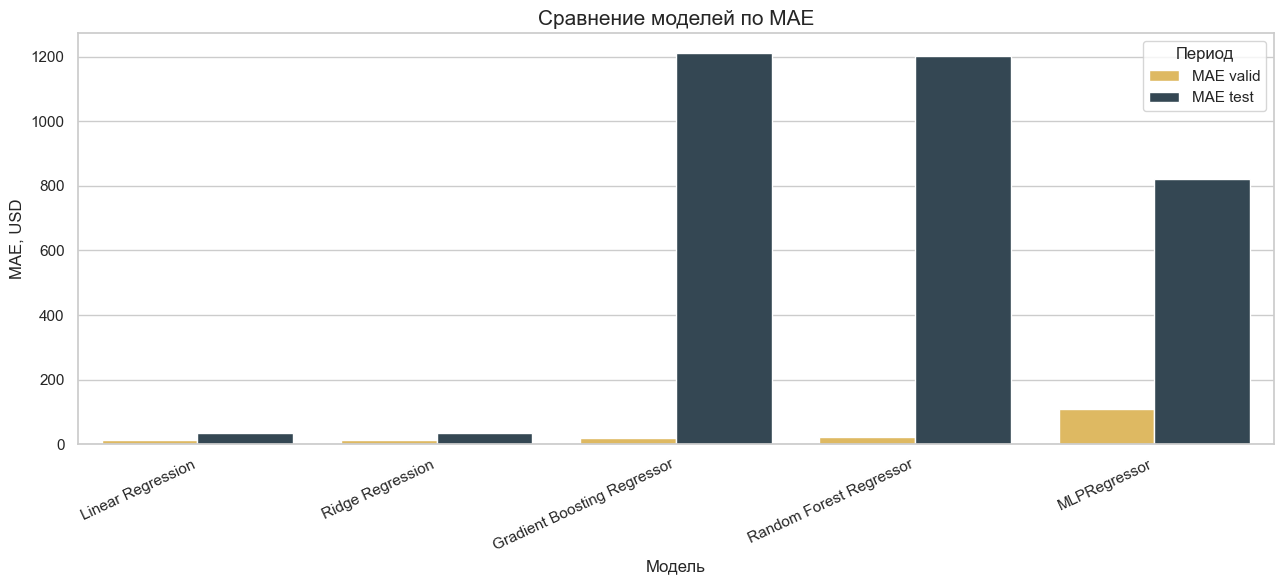

Лучшая модель по MAE validation: Linear Regression
Параметры: {}


In [10]:
def plot_model_comparison(results: pd.DataFrame, save_path: Path):
    """Строит график сравнения моделей по MAE validation/test."""
    plot_df = results.melt(
        id_vars="Model",
        value_vars=["MAE valid", "MAE test"],
        var_name="Split",
        value_name="MAE",
    )
    plt.figure(figsize=(13, 6))
    sns.barplot(data=plot_df, x="Model", y="MAE", hue="Split", palette=["#f2c14e", "#2f4858"])
    plt.title("Сравнение моделей по MAE")
    plt.xlabel("Модель")
    plt.ylabel("MAE, USD")
    plt.xticks(rotation=25, ha="right")
    plt.legend(title="Период")
    save_current_figure(save_path)


plot_model_comparison(model_results, IMAGES_DIR / "model_comparison.png")

best_model_name = model_results.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_test_pred = test_predictions[best_model_name]

print(f"Лучшая модель по MAE validation: {best_model_name}")
print("Параметры:", model_results.iloc[0]["Best params"])

## 9. Интерпретация и анализ ошибок

Для лучшей модели строим важность признаков. Если модель не поддерживает `feature_importances_`, используем абсолютные коэффициенты линейной модели. Также анализируем ошибки во времени и сравниваем фактические значения с прогнозом.

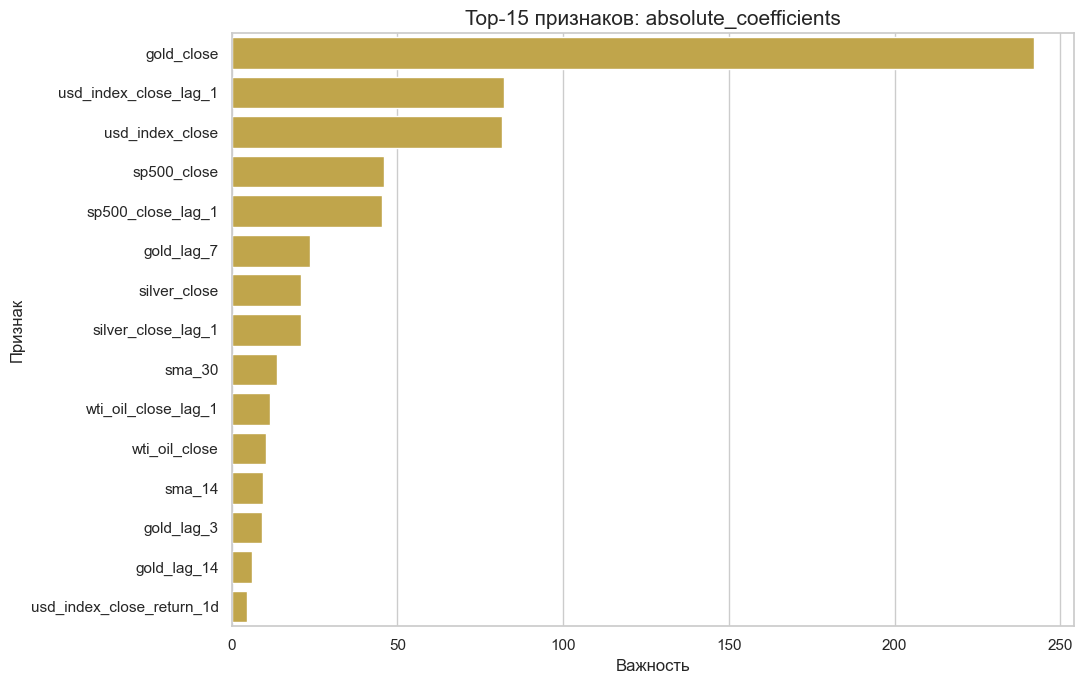

,feature,importance
0,gold_close,241.9981
1,usd_index_close_lag_1,82.2106
2,usd_index_close,81.6318
3,sp500_close,45.7858
4,sp500_close_lag_1,45.4146
5,gold_lag_7,23.6180
6,silver_close,20.8818
7,silver_close_lag_1,20.7557
8,sma_30,13.5452
9,wti_oil_close_lag_1,11.4196


In [11]:
def _unwrap_model(model):
    """Возвращает базовую модель из sklearn Pipeline, если он используется."""
    if isinstance(model, Pipeline):
        return model.named_steps.get("model", model)
    return model


def get_feature_importance(model, feature_columns):
    """Получает importance для деревьев или коэффициенты для линейных моделей."""
    core_model = _unwrap_model(model)

    if hasattr(core_model, "feature_importances_"):
        values = core_model.feature_importances_
        importance_type = "feature_importances"
    elif hasattr(core_model, "coef_"):
        values = np.abs(np.ravel(core_model.coef_))
        importance_type = "absolute_coefficients"
    else:
        return pd.DataFrame(columns=["feature", "importance"]), "not_available"

    importance = pd.DataFrame({
        "feature": feature_columns,
        "importance": values,
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    return importance, importance_type


def plot_feature_importance(model, feature_columns, save_path: Path, top_n: int = 15):
    """Строит top-N важнейших признаков лучшей модели."""
    importance, importance_type = get_feature_importance(model, feature_columns)
    if importance.empty:
        print("Для выбранной модели стандартная важность признаков недоступна.")
        return importance

    plt.figure(figsize=(11, 7))
    sns.barplot(data=importance.head(top_n), y="feature", x="importance", color="#d4af37")
    plt.title(f"Top-{top_n} признаков: {importance_type}")
    plt.xlabel("Важность")
    plt.ylabel("Признак")
    save_current_figure(save_path)
    return importance


feature_importance = plot_feature_importance(best_model, feature_columns, IMAGES_DIR / "feature_importance.png", top_n=15)
feature_importance.head(10).to_csv(DATA_DIR / "feature_importance_top10.csv", index=False)
display(feature_importance.head(10))

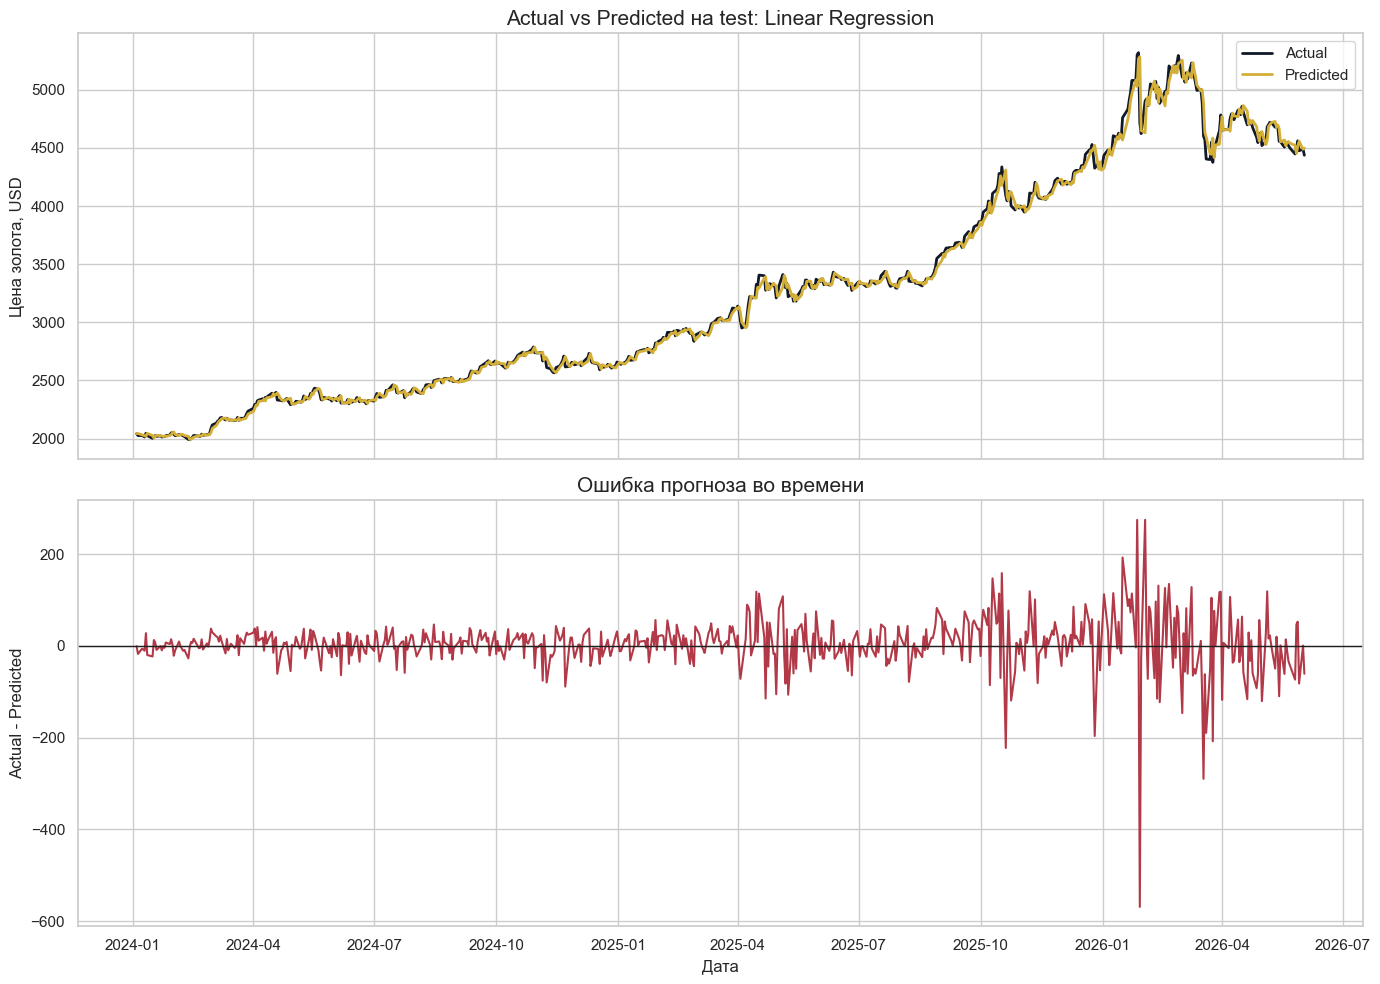

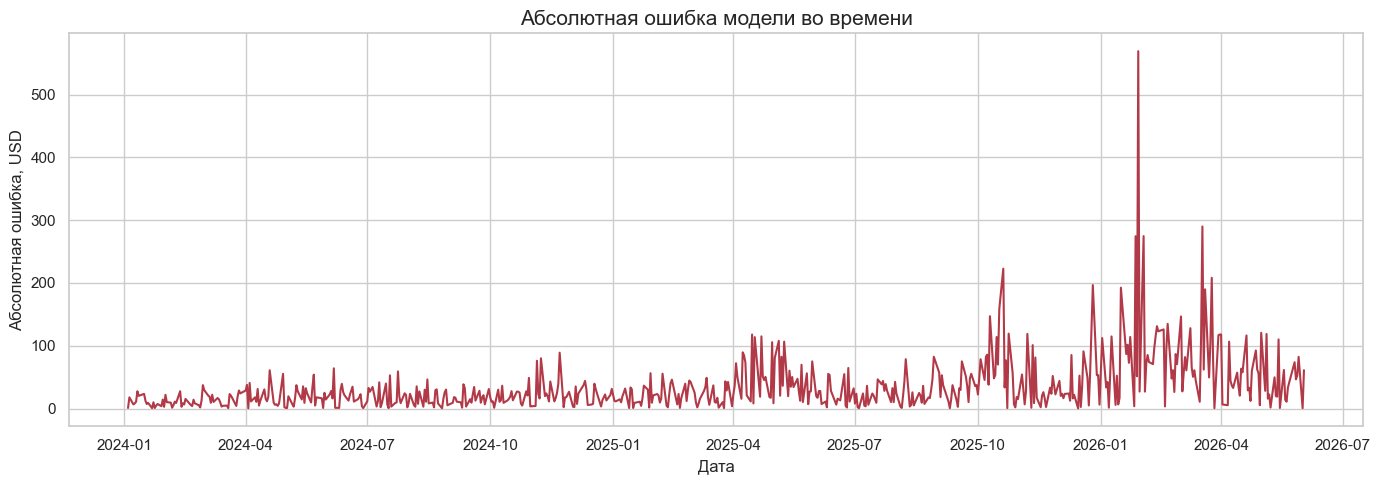

Периоды с максимальной ошибкой:


,date,actual,predicted,abs_error
521,2026-01-29,"4,713.8999","5,282.8875",568.9876
554,2026-03-18,"4,600.7002","4,890.5405",289.8403
523,2026-02-02,"4,903.7002","4,629.1944",274.5058
519,2026-01-27,"5,301.6001","5,027.2822",274.3179
452,2025-10-20,"4,087.7000","4,310.4026",222.7027
559,2026-03-25,"4,375.5000","4,583.6181",208.1181
499,2025-12-26,"4,325.1001","4,521.6395",196.5394
513,2026-01-16,"4,759.6001","4,567.2212",192.3789
556,2026-03-20,"4,404.1001","4,593.8876",189.7875
451,2025-10-17,"4,336.3999","4,178.0647",158.3352


In [12]:
error_df = pd.DataFrame({
    "date": y_test.index,
    "actual": y_test.values,
    "predicted": best_test_pred,
})
error_df["error"] = error_df["actual"] - error_df["predicted"]
error_df["abs_error"] = error_df["error"].abs()
error_df.to_csv(DATA_DIR / "test_predictions.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
axes[0].plot(error_df["date"], error_df["actual"], label="Actual", color="#111827", linewidth=2)
axes[0].plot(error_df["date"], error_df["predicted"], label="Predicted", color="#d4af37", linewidth=2)
axes[0].set_title(f"Actual vs Predicted на test: {best_model_name}")
axes[0].set_ylabel("Цена золота, USD")
axes[0].legend()

axes[1].plot(error_df["date"], error_df["error"], color="#b23a48", linewidth=1.5)
axes[1].axhline(0, color="#202020", linewidth=1)
axes[1].set_title("Ошибка прогноза во времени")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("Actual - Predicted")
save_current_figure(IMAGES_DIR / "actual_vs_predicted.png")

plt.figure(figsize=(14, 5))
sns.lineplot(data=error_df, x="date", y="abs_error", color="#b23a48")
plt.title("Абсолютная ошибка модели во времени")
plt.xlabel("Дата")
plt.ylabel("Абсолютная ошибка, USD")
save_current_figure(IMAGES_DIR / "errors_over_time.png")

worst_periods = error_df.nlargest(10, "abs_error")[["date", "actual", "predicted", "abs_error"]]
print("Периоды с максимальной ошибкой:")
display(worst_periods)

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


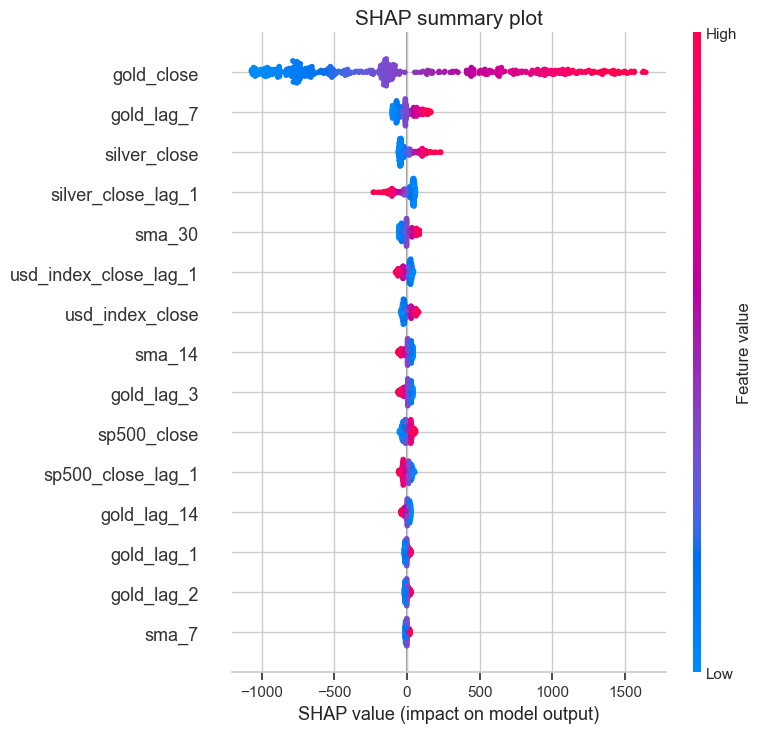

In [13]:
if SHAP_AVAILABLE and best_model_name in trained_models:
    try:
        core_model = _unwrap_model(best_model)
        sample_size = min(500, X_test.shape[0])
        X_shap = X_test.iloc[-sample_size:].copy()

        if isinstance(best_model, Pipeline):
            # Для pipeline с scaler передаем трансформированные признаки базовой модели.
            X_shap_values = best_model.named_steps["scaler"].transform(X_shap)
            X_shap_for_plot = pd.DataFrame(X_shap_values, columns=feature_columns, index=X_shap.index)
        else:
            X_shap_for_plot = X_shap

        explainer = shap.Explainer(core_model, X_shap_for_plot)
        shap_values = explainer(X_shap_for_plot)
        shap.summary_plot(shap_values, X_shap_for_plot, show=False, max_display=15)
        plt.title("SHAP summary plot")
        save_current_figure(IMAGES_DIR / "shap_summary.png")
    except Exception as exc:
        print(f"SHAP-график не построен, используем стандартную важность признаков. Причина: {exc}")
else:
    print("SHAP недоступен, используется стандартная важность признаков.")

## 10. Прогноз на 30 дней

Для горизонта 30 дней используем итеративный прогноз:

1. Берем последние доступные данные.
2. Считаем признаки для последней строки.
3. Прогнозируем следующий день.
4. Добавляем предсказание как новую цену золота.
5. Внешние рыночные признаки на будущие даты держим на последнем известном уровне, потому что их будущие значения неизвестны.
6. Повторяем 30 раз.

Такой подход прост и прозрачен для учебного проекта, но важно помнить, что ошибка может накапливаться с каждым следующим шагом горизонта.

In [14]:
def _next_business_day(date_like) -> pd.Timestamp:
    """Возвращает следующий торговый/рабочий день."""
    return pd.Timestamp(date_like) + pd.offsets.BDay(1)


def forecast_next_30_days(model, last_known_data: pd.DataFrame, feature_columns: list, horizon: int = 30) -> pd.DataFrame:
    """Итеративно прогнозирует цену золота на horizon рабочих дней вперед."""
    history = last_known_data.copy().sort_index()
    forecast_rows = []

    for _ in range(horizon):
        features_for_history = prepare_features(history).replace([np.inf, -np.inf], np.nan).ffill()
        last_features = features_for_history.iloc[[-1]][feature_columns]
        prediction = float(model.predict(last_features)[0])

        next_date = _next_business_day(history.index[-1])
        new_row = history.iloc[[-1]].copy()
        new_row.index = [next_date]
        new_row["gold_close"] = prediction

        # Будущие значения внешних рынков неизвестны, поэтому используем last observation carried forward.
        for col in history.columns:
            if col != "gold_close":
                new_row[col] = history[col].ffill().iloc[-1]

        history = pd.concat([history, new_row])
        forecast_rows.append({
            "date": next_date,
            "predicted_gold_price": prediction,
        })

    return pd.DataFrame(forecast_rows)


forecast_30_days = forecast_next_30_days(best_model, market_data, feature_columns, horizon=30)
forecast_30_days.to_csv(DATA_DIR / "forecast_30_days.csv", index=False)
display(forecast_30_days.head(30))

,date,predicted_gold_price
0,2026-06-04,"4,437.9047"
1,2026-06-05,"4,444.9992"
2,2026-06-08,"4,449.1645"
3,2026-06-09,"4,457.8477"
4,2026-06-10,"4,470.2751"
5,2026-06-11,"4,474.7723"
6,2026-06-12,"4,479.9151"
7,2026-06-15,"4,481.3492"
8,2026-06-16,"4,482.6625"
9,2026-06-17,"4,485.1090"


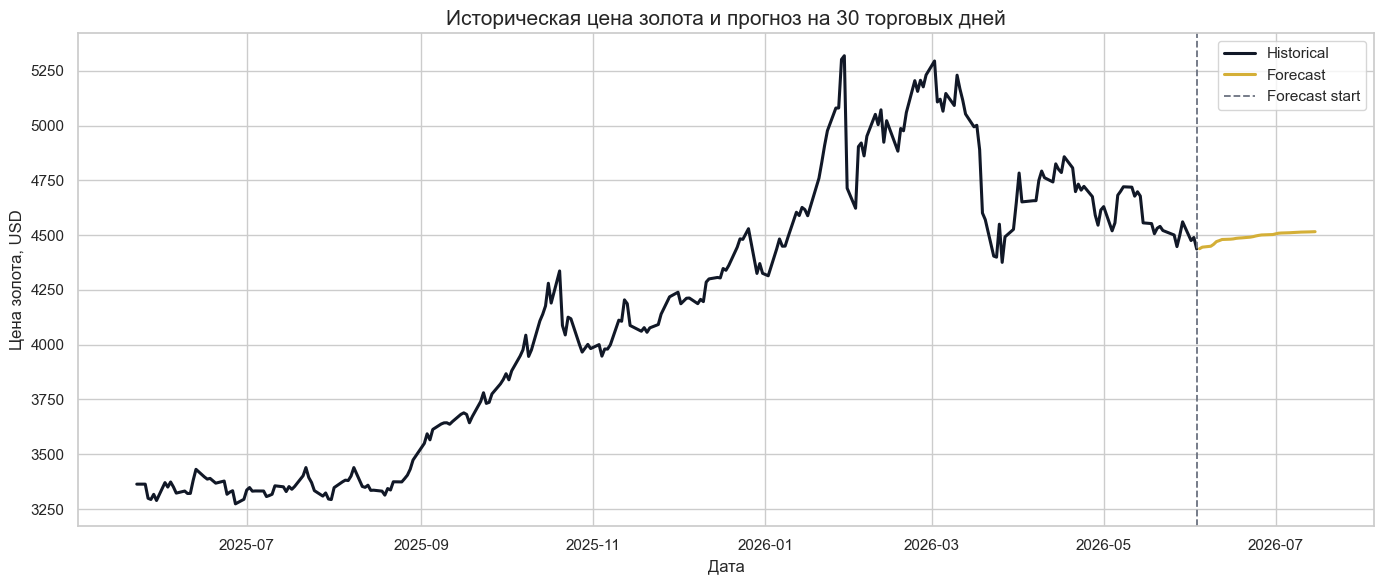

In [15]:
historical_tail = market_data[["gold_close"]].tail(260).reset_index()
historical_tail["series"] = "Historical"
historical_tail = historical_tail.rename(columns={"gold_close": "price"})

forecast_plot = forecast_30_days.rename(columns={"predicted_gold_price": "price"}).copy()
forecast_plot["series"] = "Forecast"

combined_plot = pd.concat([
    historical_tail[["date", "price", "series"]],
    forecast_plot[["date", "price", "series"]],
], ignore_index=True)

plt.figure(figsize=(14, 6))
sns.lineplot(data=combined_plot, x="date", y="price", hue="series", palette={"Historical": "#111827", "Forecast": "#d4af37"}, linewidth=2.2)
plt.axvline(market_data.index.max(), color="#6b7280", linestyle="--", linewidth=1.3, label="Forecast start")
plt.title("Историческая цена золота и прогноз на 30 торговых дней")
plt.xlabel("Дата")
plt.ylabel("Цена золота, USD")
plt.legend()
save_current_figure(IMAGES_DIR / "forecast_30_days.png")

fig = px.line(
    combined_plot,
    x="date",
    y="price",
    color="series",
    title="Интерактивный график: история и прогноз золота",
    color_discrete_map={"Historical": "#111827", "Forecast": "#d4af37"},
)
fig.show()

## 11. MLOps / Inference Example

В учебном проекте важно показать воспроизводимость:

- лучшая модель сохраняется в `models/best_model.pkl`;
- список признаков и параметры пайплайна сохраняются отдельно;
- метаданные эксперимента сохраняются в JSON;
- пример загрузки модели и инференса находится прямо в ноутбуке, без отдельного `predict.py`.

При использовании в бизнесе нужно мониторить data drift: изменение распределений цены, доходности, волатильности и внешних рыночных факторов. Если текущие данные сильно отличаются от обучающей выборки, модель нужно переобучать и валидировать заново.

In [16]:
def save_artifacts(model, feature_columns: list, metadata: dict):
    """Сохраняет модель, признаки и метаданные эксперимента."""
    MODELS_DIR.mkdir(exist_ok=True)
    joblib.dump(model, MODELS_DIR / "best_model.pkl")
    joblib.dump(feature_columns, MODELS_DIR / "feature_columns.pkl")
    joblib.dump({"feature_columns": feature_columns, "target_column": target_column}, MODELS_DIR / "feature_pipeline.pkl")

    if isinstance(model, Pipeline) and "scaler" in model.named_steps:
        joblib.dump(model.named_steps["scaler"], MODELS_DIR / "scaler.pkl")

    with open(MODELS_DIR / "metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2, default=str)


def load_artifacts():
    """Загружает сохраненную модель и список признаков."""
    model = joblib.load(MODELS_DIR / "best_model.pkl")
    features = joblib.load(MODELS_DIR / "feature_columns.pkl")
    with open(MODELS_DIR / "metadata.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)
    return model, features, metadata


metadata = {
    "project": "Gold price forecasting",
    "team": ["Юсупов Данил", "Панчук Павел", "Маликов Евгений"],
    "course": "Технологии искусственного интеллекта и продвинутой аналитики",
    "best_model": best_model_name,
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "data_start": str(market_data.index.min().date()),
    "data_end": str(market_data.index.max().date()),
    "rows": int(market_data.shape[0]),
    "columns": list(market_data.columns),
    "feature_count": len(feature_columns),
    "metrics": model_results.iloc[0].to_dict(),
    "baseline_test": baseline_results[baseline_results["Split"] == "test"].to_dict(orient="records"),
}

save_artifacts(best_model, feature_columns, metadata)

loaded_model, loaded_features, loaded_metadata = load_artifacts()
example_forecast = forecast_next_30_days(loaded_model, market_data, loaded_features, horizon=5)
print("Загруженная модель:", loaded_metadata["best_model"])
print("Пример инференса на 5 дней:")
display(example_forecast)

Загруженная модель: Linear Regression
Пример инференса на 5 дней:


,date,predicted_gold_price
0,2026-06-04,"4,437.9047"
1,2026-06-05,"4,444.9992"
2,2026-06-08,"4,449.1645"
3,2026-06-09,"4,457.8477"
4,2026-06-10,"4,470.2751"


## 12. Выводы

В проекте построен воспроизводимый ML-пайплайн для прогнозирования цены золота на следующий день и итеративного прогноза на 30 торговых дней.

Ключевые итоги:

- Использованы исторические данные золота и внешние рыночные признаки: доллар, S&P 500, нефть, серебро, доходность 10-летних облигаций США.
- Построены лаговые, rolling, volatility, return и календарные признаки.
- Применено хронологическое разделение train/validation/test без перемешивания.
- Сравнены baseline-подходы и несколько ML-моделей.
- Лучшая модель сохранена вместе со списком признаков и metadata.
- Построен прогноз на 30 дней и сохранен в `data/forecast_30_days.csv`.

Ограничения:

- Прогноз на 30 дней строится итеративно, поэтому ошибка может накапливаться.
- Будущие значения внешних факторов неизвестны и в текущей версии фиксируются на последнем наблюдении.
- Модель не использует новости, макроэкономические релизы и sentiment analysis.
- Для реального бизнеса необходимы backtesting, мониторинг drift и регулярное переобучение.

Возможные улучшения:

- добавить макроэкономические индикаторы и процентные ставки;
- использовать новости и sentiment analysis;
- реализовать rolling backtesting;
- сравнить с ARIMA/Prophet/TFT/LSTM;
- автоматизировать переобучение и мониторинг качества модели.